# Assignment 4

assumptions: isothermal, heat of reaction negligible -> only mass balance considered, rate constant not temperature dependent

\begin{align*}
    A \rightarrow B
\end{align*}

mass balance:

\begin{align*}
    \frac{dc_A}{d\tau}=-r
\end{align*}

\begin{align*}
    \frac{dc_B}{d\tau}=r
\end{align*}

first order:

r = k*c_A

\begin{align*}
    r=-\frac{dc_A}{d\tau}=-u\frac{dc_A}{dz}=k \cdot c_A
\end{align*}

\begin{align*}
    r=-\frac{dc_B}{d\tau}=u\frac{dc_B}{dz}
\end{align*}

## Implementation

In [1]:
import sys
import numpy as np
import scipy.integrate as integ #important for initial value problem
from scipy.integrate import solve_ivp
from scipy.integrate import solve_bvp
import matplotlib.pyplot as plt
import pandas as pd
from scipy.special import erf
from scipy.stats import gamma

### Ideal PFTR model - Initial value problem

In [2]:
#implement parameters

L = 10 #reactor length / m
d = 32 *10**-3 #reactor diameter / m
d_up = 150 * 10**(-3) # diameter upstream / m
V_dot = 1 # volumetric flow rate / m3/s
c_A_in = 100 # inlet concentration of component A / mol/m3
c_B_in = 0 # inlet concentration of component B / mol/m3
k = 1*10**3 # reaction rate constant / m3/mol/s

A = np.pi * (d/2)**2 #reactor diameter / m2
A_up = np.pi * (d_up/2)**2 #diameter upstream / m2

V_reactor = A * L # reactor volume / m3

tau = V_reactor / V_dot

theta = np.linspace(0.001, 3, 1000)   # dimensionless time theta = t/tau
t = theta * tau

u = V_dot / A                  # velocity in reactor / m/s
u_up = V_dot / A_up            # velocity upstream / m/s

# Boundary case: very large Bo -> nearly ideal PFTR
Bo = 10000
D_ax = u * L / Bo              # axial dispersion coefficient / m2/s

print("u =", u, "m/s")
print("D_ax =", D_ax, "m2/s")


def kinetics(c_A):
    r=k*c_A # reaction rate / mol/m3/s
    return r

u = 1243.3979929054324 m/s
D_ax = 1.2433979929054324 m2/s


Ideal PFTR

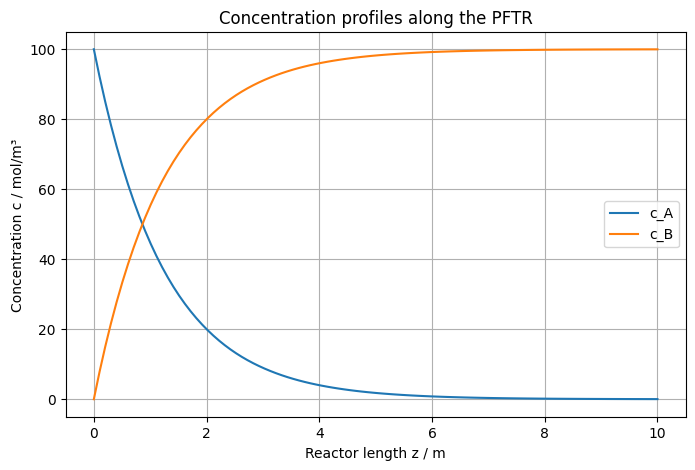

In [3]:
def PFTR_id(z, f):
    'ideal PFTR model'
    # f is a vector containing concentrations of components c_A (f[0]) and c_B (f[1])
    c_A = f[0]
    c_B = f[1]
    
    # reaction rate from kinetics function
    r = kinetics(c_A)
    
    # differential equations
    dc_A_dz = -r/u #change in concentration of B along the reactor length / mol/m^3/m
    dc_B_dz = r/u #change in concentration of C along the reactor length / mol/m^3/m
    
    dfdz = np.empty_like(f)
    dfdz[0] = dc_A_dz
    dfdz[1] = dc_B_dz
    return dfdz

# vector of initial conditions
f_init = np.array([c_A_in, 0]) #initial concentrations of A and B

# solve the system of ODEs using scipy's solve_ivp
tspan = (0, L) #span of the reactor length
zeval = np.linspace(0, L, 100) #points at which to evaluate the solution
sol_id = integ.solve_ivp(PFTR_id, tspan, f_init, t_eval=zeval)

# Plot concentration c over reactor length z

plt.figure(figsize=(8, 5))

plt.plot(sol_id.t, sol_id.y[0], label='c_A')
plt.plot(sol_id.t, sol_id.y[1], label='c_B')

plt.xlabel('Reactor length z / m')
plt.ylabel('Concentration c / mol/m³')
plt.title('Concentration profiles along the PFTR')
plt.grid(True)
plt.legend()
plt.show()

### Boundary Value Problem

$$
u \frac{\text{d}c_i}{\text{d}z} = \mathcal{D} \frac{\text{d}^2 c_i }{\text{d} z^2} + \sum_{j=1}^{M} \nu_{i,j} r_j
$$

boundary case D=0 ideal PFTR model
higher dispersion coefficient, wider residence time distribution

Bodenstein-Number, convective mass transfer compared to backmixing

$$
Bo = \frac{u \, L}{\mathcal{D}}
$$


The algorithm converged to the desired accuracy.


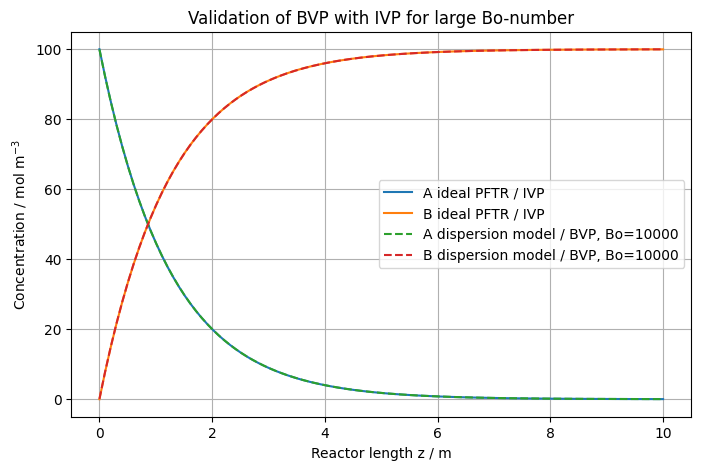

In [4]:
def PFTR_re(z, y):
    'real PFTR model with axial dispersion'
    c_A = y[0]
    dc_A_dz = y[1]
    c_B = y[2]
    dc_B_dz = y[3]
    
    r = kinetics(c_A)
    
    d2c_A_dz2 = (u * dc_A_dz + r) / D_ax
    d2c_B_dz2 = (u * dc_B_dz - r) / D_ax
    
    return np.vstack((dc_A_dz, d2c_A_dz2,
                      dc_B_dz, d2c_B_dz2))
    
def bc(ya, yb):
    'Danckwerts boundary conditions'
    # ya = values at z = 0
    # yb = values at z = L
    
    bc_A_in = u_up * A_up * c_A_in - (u * A * ya[0] - A * D_ax * ya[1])
    bc_B_in = u_up * A_up * c_B_in - (u * A * ya[2] - A * D_ax * ya[3])
    
    bc_A_out = yb[1]       # dcA/dz at z=L = 0
    bc_B_out = yb[3]       # dcB/dz at z=L = 0
    
    return np.array([bc_A_in, bc_B_in, bc_A_out, bc_B_out])

z = np.linspace(0, L, 200)

# Initial guess for BVP
y_init = np.zeros((4, z.size))
y_init[0] = c_A_in * np.exp(-k/u * z)       # guess for c_A
y_init[2] = c_A_in - y_init[0]              # guess for c_B

sol_re = solve_bvp(
    PFTR_re,
    bc,
    z,
    y_init,
    max_nodes=10000
)

print(sol_re.message)

plt.figure(figsize=(8,5))

plt.plot(sol_id.t, sol_id.y[0], label="A ideal PFTR / IVP")
plt.plot(sol_id.t, sol_id.y[1], label="B ideal PFTR / IVP")

plt.plot(sol_re.x, sol_re.y[0], "--", label=f"A dispersion model / BVP, Bo={Bo}")
plt.plot(sol_re.x, sol_re.y[2], "--", label=f"B dispersion model / BVP, Bo={Bo}")

plt.xlabel("Reactor length z / m")
plt.ylabel("Concentration / mol m$^{-3}$")
plt.title("Validation of BVP with IVP for large Bo-number")
plt.grid(True)
plt.legend()
plt.show()

### Task 2

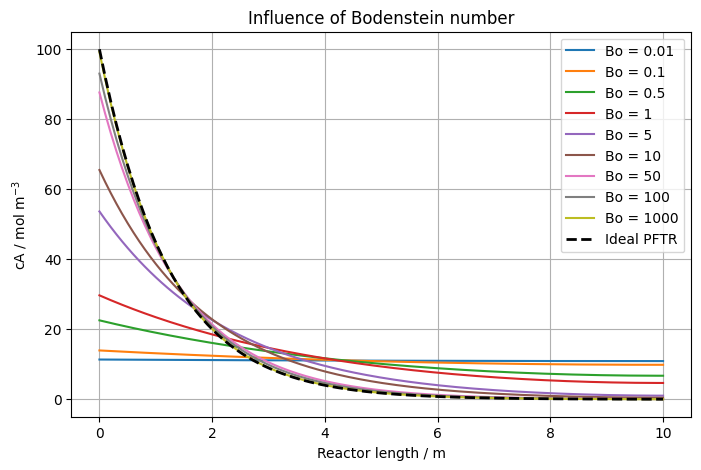

In [5]:
Bo_list = [0.01, 0.1, 0.5, 1, 5, 10, 50, 100, 1000]

plt.figure(figsize=(8,5))

for Bo in Bo_list:

    D_ax = u * L / Bo

    sol_re = solve_bvp(
        PFTR_re,
        bc,
        z,
        y_init,
        max_nodes=10000
    )

    plt.plot(sol_re.x,
             sol_re.y[0],
             label=f"Bo = {Bo}")
    
plt.plot(sol_id.t,
         sol_id.y[0],
         "k--",
         linewidth=2,
         label="Ideal PFTR")

plt.xlabel("Reactor length / m")
plt.ylabel("cA / mol m$^{-3}$")
plt.title("Influence of Bodenstein number")
plt.grid(True)
plt.legend()
plt.show()

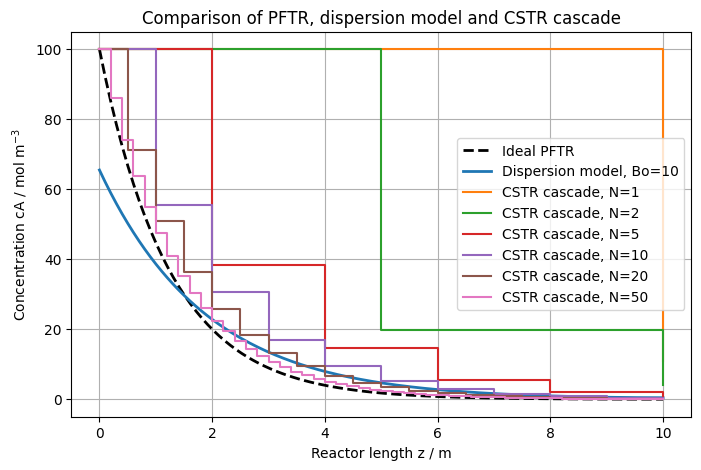

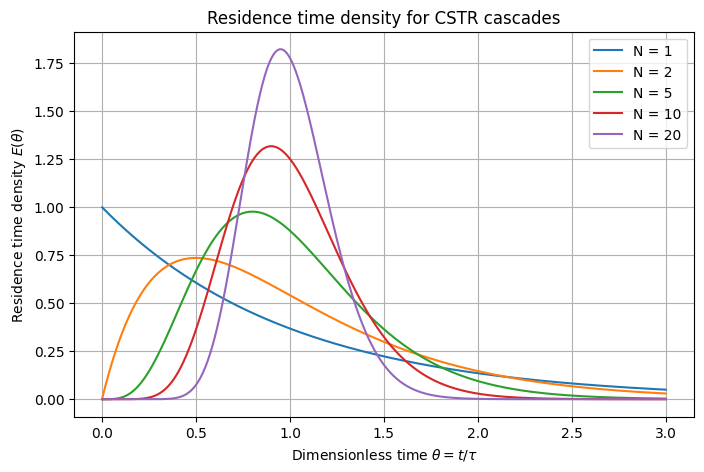

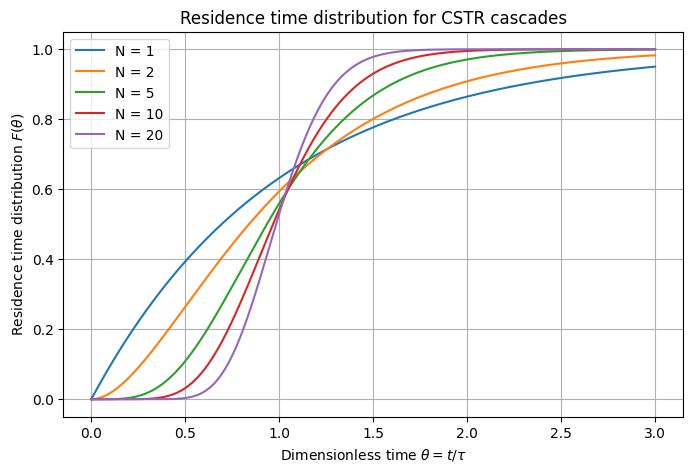

In [6]:
# Task 3: CSTR cascade

def CSTR_cascade(N):
    
    tau_total = V_reactor / V_dot
    tau_i = tau_total / N
    
    c_A_values = [c_A_in]
    c_B_values = [c_B_in]
    z_values = [0]
    
    c_A_current = c_A_in
    c_B_current = c_B_in
    
    for i in range(N):
        
        # ideal CSTR balance for first-order reaction
        c_A_out = c_A_current / (1 + k * tau_i)
        
        # stoichiometry: A -> B
        c_B_out = c_B_current + (c_A_current - c_A_out)
        
        c_A_values.append(c_A_out)
        c_B_values.append(c_B_out)
        
        z_values.append((i+1) * L / N)
        
        c_A_current = c_A_out
        c_B_current = c_B_out
    
    return np.array(z_values), np.array(c_A_values), np.array(c_B_values)

N_list = [1, 2, 5, 10, 20, 50]

plt.figure(figsize=(8,5))

# ideal PFTR
plt.plot(sol_id.t,
         sol_id.y[0],
         "k--",
         linewidth=2,
         label="Ideal PFTR")

# dispersion model, choose one Bo for comparison
Bo = 10
D_ax = u * L / Bo

sol_re = solve_bvp(
    PFTR_re,
    bc,
    z,
    y_init,
    max_nodes=10000
)

plt.plot(sol_re.x,
         sol_re.y[0],
         linewidth=2,
         label=f"Dispersion model, Bo={Bo}")

# CSTR cascades
for N in N_list:
    
    z_cstr, c_A_cstr, c_B_cstr = CSTR_cascade(N)
    
    plt.step(z_cstr,
             c_A_cstr,
             where="post",
             label=f"CSTR cascade, N={N}")

plt.xlabel("Reactor length z / m")
plt.ylabel("Concentration cA / mol m$^{-3}$")
plt.title("Comparison of PFTR, dispersion model and CSTR cascade")
plt.grid(True)
plt.legend()
plt.show()

N_list = [1, 2, 5, 10, 20]

plt.figure(figsize=(8,5))

for N in N_list:
    E_cascade = gamma.pdf(theta, a=N, scale=1/N)
    plt.plot(theta, E_cascade, label=f"N = {N}")

plt.xlabel(r"Dimensionless time $\theta = t/\tau$")
plt.ylabel(r"Residence time density $E(\theta)$")
plt.title("Residence time density for CSTR cascades")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(8,5))

for N in N_list:
    F_cascade = gamma.cdf(theta, a=N, scale=1/N)
    plt.plot(theta, F_cascade, label=f"N = {N}")

plt.xlabel(r"Dimensionless time $\theta = t/\tau$")
plt.ylabel(r"Residence time distribution $F(\theta)$")
plt.title("Residence time distribution for CSTR cascades")
plt.grid(True)
plt.legend()
plt.show()